# NMR ¹H-¹⁵N HSQC Chemical Shift Prediction
**Pipeline:** PDB → Custom Geometric Embeddings → GCN → (δ¹H, δ¹⁵N) per residue

**Steps before running:**
1. `Runtime > Change runtime type > T4 GPU`
2. `Ctrl+F9` (Run All)
3. Data + checkpoints are saved to Google Drive — safe to resume after session reset


In [1]:
import subprocess
import sys
import torch

def install_packages():
    # Determine PyTorch and CUDA versions for PyG extensions
    tv = torch.__version__.split("+")[0]
    cv = torch.version.cuda.replace(".", "") if torch.cuda.is_available() else "cpu"

    packages = [
        "torch-geometric",
        "biopython",
        "pynmrstar",
        "tqdm",
        "scipy",
        "seaborn",
        "pandas",
        "requests",
        "scikit-learn"
    ]

    print("Installing base packages...")
    subprocess.run([sys.executable, "-m", "pip", "install", *packages, "-q"], check=True)

    print(f"Installing PyG extensions for torch-{tv}+cu{cv}...")
    pyg_ext = ["torch-scatter", "torch-sparse"]
    find_url = f"https://data.pyg.org/whl/torch-{tv}+cu{cv}.html"
    subprocess.run([sys.executable, "-m", "pip", "install", *pyg_ext, "-f", find_url, "-q"], check=True)

    print("All dependencies installed successfully.")

install_packages()

Installing base packages...
Installing PyG extensions for torch-2.10.0+cu128...
All dependencies installed successfully.


In [2]:
# ── GPU check ──────────────────────────────────────────────
import torch

if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("WARNING: No GPU — go to Runtime > Change runtime type > T4 GPU")


GPU : Tesla T4
VRAM: 15.6 GB


In [3]:
# ── Mount Google Drive ─────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted at /content/drive")


Mounted at /content/drive
Drive mounted at /content/drive


In [4]:
# ── Install packages ───────────────────────────────────────
import subprocess, sys, torch

def pip(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", *args, "-q"], check=True)

pip("torch-geometric")

# Optional PyG C++ extensions (speed up sparse ops)
tv  = torch.__version__.split("+")[0]
cv  = torch.version.cuda.replace(".", "") if torch.cuda.is_available() else "cpu"
pip("torch-scatter", "torch-sparse",
    "-f", f"https://data.pyg.org/whl/torch-{tv}+cu{cv}.html")

pip("biopython", "pynmrstar", "tqdm", "scipy", "seaborn")
print("All packages installed.")


All packages installed.


In [5]:
# ── Configuration — edit this cell to tune the run ────────
CFG = dict(
    # Paths (all under your Drive)
    drive_root   = "/content/drive/MyDrive/nmr_hsqc_predictor",

    # Data
    max_entries  = 50000,           # BMRB entries to download

    # Geometric embedding
    space_dist   = 5.0,           # Å, through-space neighbor cutoff
    seq_range    = 3,             # i±3 sequence neighbors
    max_nb       = 128,           # max neighbors per residue
    bb_cutoff    = 1.0,           # backbone RMSD filter (NMR ensembles)
    nb_cutoff    = 1.5,           # neighbor atom RMSD filter

    # Graph edges
    edge_dist    = 8.0,           # Å, spatial edge cutoff
    edge_seq     = 3,             # sequence edge range

    # Training
    node_feat_dim = 1792,         # 128 × 14 (fixed by embedding design)
    hidden_dim    = 256,
    num_layers    = 4,
    batch_size    = 32,
    epochs        = 200,
    lr            = 1e-3,
    weight_decay  = 1e-4,
    patience      = 20,
    seed          = 42,
)

# Derived paths
import os
R = CFG["drive_root"]
BMRB_DIR   = f"{R}/data/raw/bmrb"
PDB_DIR    = f"{R}/data/raw/pdb"
MANIFEST   = f"{R}/data/raw/manifest.json"
GRAPHS_PKL = f"{R}/data/processed/graphs.pkl"
SPLITS_DIR = f"{R}/data/splits"
CKPT_GCN   = f"{R}/checkpoints/best_gcn.pt"
CKPT_MLP   = f"{R}/checkpoints/best_mlp.pt"
OUTPUT_DIR = f"{R}/output"

for d in [BMRB_DIR, PDB_DIR, f"{R}/data/processed",
          SPLITS_DIR, f"{R}/checkpoints", OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

print("Directories ready under", R)


Directories ready under /content/drive/MyDrive/nmr_hsqc_predictor


In [6]:
# ── Imports ────────────────────────────────────────────────
import json, os, pickle, time, logging
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoLoader
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(CFG["seed"])
print(f"Using device: {DEVICE}")


Using device: cuda


## 1 · Data Download
Fetches ~500 BMRB NMR-STAR files + linked PDB structures. Resumable.

In [7]:
BMRB_API = "https://api.bmrb.io/v2"
BMRB_FTP = "https://bmrb.io/ftp/pub/bmrb/entry_directories"
RCSB_URL = "https://files.rcsb.org/download"

def get_mapping():
    r = requests.get(f"{BMRB_API}/mappings/bmrb/pdb", timeout=60)
    r.raise_for_status()
    data = r.json()
    mapping = {}
    for entry in data:
        b_id = str(entry.get('bmrb_id'))
        p_ids = entry.get('pdb_ids', [])
        if b_id and p_ids:
            mapping[b_id] = [p.upper() for p in p_ids]
    return mapping

def dl_bmrb(bmrb_id):
    fname = f"bmr{bmrb_id}_3.str"
    dest  = os.path.join(BMRB_DIR, fname)
    if os.path.exists(dest): return dest
    try:
        r = requests.get(f"{BMRB_FTP}/bmr{bmrb_id}/{fname}", timeout=60)
        r.raise_for_status()
        with open(dest, "wb") as f: f.write(r.content)
        return dest
    except Exception: return None

def dl_pdb(pdb_id):
    pid  = pdb_id.lower()
    dest = os.path.join(PDB_DIR, f"{pid}.pdb")
    if os.path.exists(dest): return dest
    try:
        r = requests.get(f"{RCSB_URL}/{pid}.pdb", timeout=60)
        r.raise_for_status()
        with open(dest, "wb") as f: f.write(r.content)
        return dest
    except Exception: return None

manifest = []
if os.path.exists(MANIFEST):
    with open(MANIFEST) as f: manifest = json.load(f)
    ok = sum(1 for r in manifest if r.get("ok"))
    print(f"Resuming: {len(manifest)} processed, {ok} valid pairs so far")
already = {r["bmrb_id"] for r in manifest}

print("Fetching BMRB→PDB mapping …")
mapping = get_mapping()
print(f"  {len(mapping)} entries with linked PDB")

candidates = sorted(mapping.keys(), key=lambda x: int(x))
downloaded = sum(1 for r in manifest if r.get("ok"))

for bmrb_id in tqdm(candidates, desc="Downloading"):
    if downloaded >= CFG["max_entries"]: break
    if bmrb_id in already:
        if any(r["bmrb_id"] == bmrb_id and r.get("ok") for r in manifest): downloaded += 1
        continue

    pdb_id = mapping[bmrb_id][0]
    bp = dl_bmrb(bmrb_id)
    pp = dl_pdb(pdb_id)
    ok = bp is not None and pp is not None

    manifest.append({"bmrb_id": bmrb_id, "pdb_id": pdb_id, "bmrb_path": bp, "pdb_path": pp, "ok": ok})
    if ok: downloaded += 1
    with open(MANIFEST, "w") as f: json.dump(manifest, f)
    time.sleep(0.1)

valid = [r for r in manifest if r.get("ok")]
print(f"\nDone: {len(valid)} valid BMRB+PDB pairs")

Resuming: 8705 processed, 8646 valid pairs so far
Fetching BMRB→PDB mapping …
  8705 entries with linked PDB


Downloading:   0%|          | 0/8705 [00:00<?, ?it/s]


Done: 8646 valid BMRB+PDB pairs


## 2 · Parsing
Extract amide shifts from NMR-STAR; parse atom coordinates from PDB.

In [8]:
# ── BMRB parser ────────────────────────────────────────────
import pynmrstar

AMIDE_H = {"H", "HN", "H1"}

def parse_hsqc_shifts(star_file):
    """Returns {(chain, seq_id, res_name): (dH, dN)}"""
    try:
        entry = pynmrstar.Entry.from_file(star_file)
    except Exception:
        return {}

    loops = []
    try:
        loops = entry.get_loops_by_category("Atom_chem_shift")
    except AttributeError:
        for sf in entry:
            for lp in sf:
                if hasattr(lp, "tags") and any(
                    "atom_chem_shift" in t.lower() for t in lp.tags
                ):
                    loops.append(lp)

    result = {}
    for loop in loops:
        try:
            tags = [t.split(".")[-1].lower() for t in loop.tags]
            needed = {"atom_id", "val", "seq_id", "comp_id"}
            if not needed.issubset(tags):
                continue
            idx = {t: i for i, t in enumerate(tags)}
            shifts = {}

            for row in loop.data:
                atom = str(row[idx["atom_id"]]).upper()
                val_raw = row[idx["val"]]
                comp    = str(row[idx["comp_id"]]).upper()
                if comp == "PRO" or val_raw in (".", "?", "", None):
                    continue
                try:
                    val = float(val_raw)
                    seq = int(row[idx["seq_id"]])
                except (ValueError, TypeError):
                    continue

                chain = "1"
                if "entity_assembly_id" in idx:
                    chain = str(row[idx["entity_assembly_id"]])

                key = (chain, seq, comp)
                shifts.setdefault(key, {})

                is_h = atom in AMIDE_H
                is_n = atom == "N"

                if "atom_isotope_number" in idx:
                    iso_raw = row[idx["atom_isotope_number"]]
                    if iso_raw not in (".", "?", None):
                        try:
                            iso = int(iso_raw)
                            if is_h and iso != 1:  is_h = False
                            if is_n and iso != 15: is_n = False
                        except ValueError:
                            pass

                if is_h and "H" not in shifts[key]: shifts[key]["H"] = val
                if is_n and "N" not in shifts[key]: shifts[key]["N"] = val

            for key, d in shifts.items():
                if "H" in d and "N" in d:
                    result[key] = (d["H"], d["N"])
        except Exception:
            continue
    return result


In [9]:
# ── PDB parser (handles NMR ensembles) ─────────────────────
from Bio.PDB import PDBParser as _PDBParser

_parser = _PDBParser(QUIET=True)
BB_ATOMS = {"N", "CA", "C", "O"}

def load_residue_atoms(pdb_file, bb_cutoff=1.0):
    """
    #Returns (residue_atoms, flexible_ok).
    #residue_atoms : {(chain, seq, res): [{name, coord, coord_std, element, rmsd}]}
    #flexible_ok   : set of keys passing RMSD filter (None for single-model)
    """
    struct   = _parser.get_structure("X", pdb_file)
    n_models = len(list(struct.get_models()))

    if n_models > 1:
        # NMR ensemble: average + std across models
        coords_by_atom = defaultdict(list)
        for model in struct.get_models():
            for chain in model:
                for res in chain:
                    hf, seq_id, _ = res.id
                    if hf.strip(): continue
                    for atom in res.get_atoms():
                        key = (chain.id, seq_id, res.resname.strip(), atom.name)
                        coords_by_atom[key].append(atom.coord.copy())

        stats = {}
        for key, cl in coords_by_atom.items():
            arr  = np.array(cl, dtype=np.float32)
            mean = arr.mean(0)
            std  = arr.std(0)
            rmsd = float(np.sqrt(((arr - mean)**2).sum(1).mean()))
            stats[key] = {"mean": mean, "std": std, "rmsd": rmsd}

        # Group into residues
        res_atoms = defaultdict(list)
        for (ch, sq, rn, an), s in stats.items():
            res_atoms[(ch, sq, rn)].append({
                "name": an, "coord": s["mean"], "coord_std": s["std"],
                "element": an[0].upper(), "rmsd": s["rmsd"]
            })

        # Backbone RMSD filter
        bb_rmsds = defaultdict(list)
        for (ch, sq, rn, an), s in stats.items():
            if an in BB_ATOMS:
                bb_rmsds[(ch, sq, rn)].append(s["rmsd"])
        flex_ok = {k for k, v in bb_rmsds.items()
                   if v and np.mean(v) < bb_cutoff}

        return dict(res_atoms), flex_ok

    else:
        # X-ray: single model, zero std
        res_atoms = {}
        for model in struct.get_models():
            for chain in model:
                for res in chain:
                    hf, seq_id, _ = res.id
                    if hf.strip(): continue
                    key = (chain.id, seq_id, res.resname.strip())
                    res_atoms[key] = [{
                        "name": a.name, "coord": a.coord.copy(),
                        "coord_std": np.zeros(3, np.float32),
                        "element": (a.element or a.name[0]).upper(),
                        "rmsd": 0.0
                    } for a in res.get_atoms()]
            break
        return res_atoms, None


## 3 · Custom Geometric Embeddings
Local coordinate frame per residue + 128 neighbor atoms → 1792-dim vector.

In [11]:
ELEMENTS = ["C", "N", "O", "S", "H"]      # +1 "other" bin
FPB = 3 + 3 + 1 + 1 + len(ELEMENTS) + 1   # features per neighbor = 14

def one_hot_elem(e):
    v = [0.0] * (len(ELEMENTS) + 1)
    c = e.strip().upper()[:1]
    v[ELEMENTS.index(c) if c in ELEMENTS else -1] = 1.0
    return v

def build_local_frame(N, Ca, C):
    #""""Returns 3×3 rotation R: R@(Ca-N)→+X, R@(C-N) in +Y half-plane."""

    ca, c = Ca - N, C - N

    ca_xy = np.array([ca[0], ca[1], 0.])
    nxy = np.linalg.norm(ca_xy)
    Rz = np.eye(3) if nxy < 1e-8 else np.array([
        [ ca_xy[0]/nxy, -ca_xy[1]/nxy, 0],
        [ ca_xy[1]/nxy,  ca_xy[0]/nxy, 0],
        [0, 0, 1]], dtype=np.float64)

    ca1 = Rz @ ca
    nxz = np.sqrt(ca1[0]**2 + ca1[2]**2)
    Ry = np.eye(3) if nxz < 1e-8 else np.array([
        [ ca1[0]/nxz, 0, ca1[2]/nxz],
        [0, 1, 0],
        [-ca1[2]/nxz, 0, ca1[0]/nxz]], dtype=np.float64)

    R1 = Ry @ Rz
    c1  = R1 @ c
    nyz = np.sqrt(c1[1]**2 + c1[2]**2)
    Rx  = np.eye(3) if nyz < 1e-8 else np.array([
        [1, 0, 0],
        [0,  c1[1]/nyz, -c1[2]/nyz],
        [0,  c1[2]/nyz,  c1[1]/nyz]], dtype=np.float64)
    return Rx @ R1

def _get(atoms, name):
    for a in atoms:
        if a["name"] == name: return a["coord"]
    return None

def embed_residue(key, res_atoms, seq_order, cfg):
    atoms = res_atoms.get(key)
    if not atoms: return None
    N, Ca, C = _get(atoms,"N"), _get(atoms,"CA"), _get(atoms,"C")
    if N is None or Ca is None or C is None: return None

    R = build_local_frame(N, Ca, C)
    ch, sq, _ = key
    my_i = next((i for i,k in enumerate(seq_order) if k==key), None)

    rows, seen = [], set()
    for ok, oa in res_atoms.items():
        if ok == key: continue
        oc, osq, _ = ok
        if oc != ch: continue
        oi = next((i for i,k in enumerate(seq_order) if k==ok), None)
        in_seq = int(my_i is not None and oi is not None and abs(oi-my_i) <= cfg["seq_range"])

        for a in oa:
            ak = (ok, a["name"])
            if ak in seen: continue
            if a.get("rmsd", 0) > cfg["nb_cutoff"]: continue
            d = np.linalg.norm(a["coord"] - N)
            in_sp = int(d <= cfg["space_dist"])
            if not in_sp and not in_seq: continue
            seen.add(ak)
            rows.append((d, a["coord"], a.get("coord_std", np.zeros(3)),
                         a["element"], float(in_sp), float(in_seq)))

    rows.sort(key=lambda x: x[0])
    feat = []
    for _, coord, std, elem, isp, iseq in rows[:cfg["max_nb"]]:
        lc = R @ (coord - N)
        ls = R @ std
        feat.extend([*lc, *ls, isp, iseq, *one_hot_elem(elem)])
    while len(feat) < cfg["max_nb"] * FPB:
        feat.extend([0.0] * FPB)
    return np.array(feat[:cfg["max_nb"]*FPB], dtype=np.float32)


In [16]:
def build_edges(node_keys, res_atoms, cfg):
    n = len(node_keys)
    nc = [_get(res_atoms.get(k,[]), 'N') for k in node_keys]
    src, dst = [], []
    for i in range(n):
        ci, si, _ = node_keys[i]
        for j in range(i+1, n):
            cj, sj, _ = node_keys[j]
            conn = (ci==cj and abs(si-sj) <= cfg['edge_seq'])
            if not conn and nc[i] is not None and nc[j] is not None:
                conn = np.linalg.norm(nc[i]-nc[j]) <= cfg['edge_dist']
            if conn:
                src += [i,j]; dst += [j,i]
    if not src: return torch.zeros((2,0), dtype=torch.long)
    return torch.tensor([src,dst], dtype=torch.long)

def process_protein(entry, cfg):
    shifts = parse_hsqc_shifts(entry['bmrb_path'])
    if not shifts: return None
    res_atoms, flex_ok = load_residue_atoms(entry['pdb_path'], cfg['bb_cutoff'])
    if not res_atoms: return None

    # Normalize keys: (seq_id, res_name)
    # We ignore chain and find intersections based on sequence position
    pdb_map = { (k[1], k[2]): k for k in res_atoms.keys() }
    bmrb_map = { (k[1], k[2]): v for k, v in shifts.items() }

    target_keys = sorted(set(pdb_map.keys()) & set(bmrb_map.keys()))
    if not target_keys: return None

    pdb_keys = [pdb_map[k] for k in target_keys]
    chain_ord = defaultdict(list)
    for k in sorted(res_atoms.keys(), key=lambda x: x[1]):
        chain_ord[k[0]].append(k)
    seq_order = [k for v in chain_ord.values() for k in v]

    feats = {}
    for k in pdb_keys:
        if flex_ok is not None and k not in flex_ok: continue
        v = embed_residue(k, res_atoms, seq_order, cfg)
        if v is not None: feats[k] = v

    valid_pdb_keys = [k for k in pdb_keys if k in feats]
    if len(valid_pdb_keys) < 5: return None

    X = np.stack([feats[k] for k in valid_pdb_keys])
    y = np.array([bmrb_map[(k[1], k[2])] for k in valid_pdb_keys], dtype=np.float32)
    ei = build_edges(valid_pdb_keys, res_atoms, cfg)

    return Data(x=torch.tensor(X, dtype=torch.float32), edge_index=ei,
                y=torch.tensor(y, dtype=torch.float32), num_nodes=len(valid_pdb_keys))

# Re-run graph generation
graph_map = {}
valid_entries = [r for r in manifest if r.get('ok')]
skip = 0
for entry in tqdm(valid_entries, desc='Processing proteins'):
    try:
        data = process_protein(entry, CFG)
        if data: graph_map[entry['bmrb_id']] = data
        else: skip += 1
    except Exception: skip += 1

with open(GRAPHS_PKL, 'wb') as f: pickle.dump(graph_map, f)
print(f'Total proteins with graphs: {len(graph_map)} ({skip} skipped)')

Processing proteins:   0%|          | 0/8646 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [13]:
sample_entry = [r for r in manifest if r.get('ok')][0]
print(f"Inspecting entry: BMRB {sample_entry['bmrb_id']} / PDB {sample_entry['pdb_id']}")

# Load PDB data
res_atoms, flex_ok = load_residue_atoms(sample_entry['pdb_path'], CFG['bb_cutoff'])

# Inspect first few keys and residue content
keys = list(res_atoms.keys())
print(f"\nSample Residue Keys (Chain, SeqID, ResName):\n{keys[:5]}")

sample_key = keys[0]
print(f"\nAtoms in residue {sample_key}:")
atom_names = [a['name'] for a in res_atoms[sample_key]]
print(atom_names)

# Check BMRB keys for comparison
shifts = parse_hsqc_shifts(sample_entry['bmrb_path'])
bmrb_keys = list(shifts.keys())
print(f"\nSample BMRB Keys (Chain, SeqID, ResName):\n{bmrb_keys[:5]}")

Inspecting entry: BMRB 3322 / PDB 1E8P

Sample Residue Keys (Chain, SeqID, ResName):
[('A', 1, 'ALA'), ('A', 2, 'SER'), ('A', 3, 'CYS'), ('A', 4, 'TRP'), ('A', 5, 'ALA')]

Atoms in residue ('A', 1, 'ALA'):
['N', 'CA', 'C', 'O', 'CB', 'H1', 'H2', 'H3', 'HA', 'HB1', 'HB2', 'HB3']

Sample BMRB Keys (Chain, SeqID, ResName):
[('1', 2, 'SER'), ('1', 3, 'CYS'), ('1', 4, 'TRP'), ('1', 5, 'ALA'), ('1', 6, 'GLN')]


In [14]:
import pickle
with open(GRAPHS_PKL, 'rb') as f:
    graph_map = pickle.load(f)
print(f"Loaded {len(graph_map)} proteins from cache")

Loaded 0 proteins from cache


In [15]:
# ── Protein-level 70/20/10 split ──────────────────────────
pids = sorted(graph_map.keys())
train_ids, tmp = train_test_split(pids, test_size=0.30, random_state=CFG["seed"])
val_ids, test_ids = train_test_split(tmp,  test_size=0.333, random_state=CFG["seed"])

for name, ids in [("train", train_ids), ("val", val_ids), ("test", test_ids)]:
    Path(SPLITS_DIR).mkdir(exist_ok=True)
    with open(f"{SPLITS_DIR}/{name}.txt", "w") as f:
        f.write("\n".join(ids))

class HSQCDataset:
    def __init__(self, ids): self._d = [graph_map[i] for i in ids if i in graph_map]
    def __len__(self):       return len(self._d)
    def __getitem__(self, i): return self._d[i]

from torch_geometric.data import Batch

train_ds = HSQCDataset(train_ids)
val_ds   = HSQCDataset(val_ids)
test_ds  = HSQCDataset(test_ids)

print(f"Split — train: {len(train_ds)}  val: {len(val_ds)}  test: {len(test_ds)} proteins")

BS = CFG["batch_size"]
train_loader = GeoLoader(train_ds, batch_size=BS, shuffle=True)
val_loader   = GeoLoader(val_ds,   batch_size=BS, shuffle=False)
test_loader  = GeoLoader(test_ds,  batch_size=BS, shuffle=False)


ValueError: With n_samples=0, test_size=0.3 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

## 4 · Models

In [8]:
from torch_geometric.nn import GCNConv

class NMRShiftGCN(nn.Module):
    def __init__(self, feat_dim, hidden=256, layers=4, dropout=0.1):
        super().__init__()
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.convs.append(GCNConv(feat_dim, hidden))
        self.norms.append(nn.LayerNorm(hidden))
        for _ in range(layers - 1):
            self.convs.append(GCNConv(hidden, hidden))
            self.norms.append(nn.LayerNorm(hidden))
        self.drop = dropout
        self.head = nn.Sequential(
            nn.Linear(hidden, 128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, 2)
        )
    def forward(self, x, edge_index, batch=None):
        for conv, norm in zip(self.convs, self.norms):
            x = F.dropout(norm(F.relu(conv(x, edge_index))),
                          p=self.drop, training=self.training)
        return self.head(x)


class NMRShiftMLP(nn.Module):
    def __init__(self, feat_dim, hidden=256, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, hidden), nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden),   nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 2)
        )
    def forward(self, x, edge_index=None, batch=None):
        return self.net(x)

F_DIM = CFG["node_feat_dim"]
H_DIM = CFG["hidden_dim"]
gcn_model = NMRShiftGCN(F_DIM, H_DIM, CFG["num_layers"]).to(DEVICE)
mlp_model = NMRShiftMLP(F_DIM, H_DIM).to(DEVICE)
print(f"GCN params: {sum(p.numel() for p in gcn_model.parameters()):,}")
print(f"MLP params: {sum(p.numel() for p in mlp_model.parameters()):,}")


GCN params: 691,586
MLP params: 526,338


## 5 · Training

In [ ]:
def eval_mae(model, loader):
    model.eval()
    totH = totN = n = 0
    with torch.no_grad():
        for b in loader:
            b = b.to(DEVICE)
            p = model(b.x, b.edge_index, b.batch)
            d = (p - b.y).abs()
            totH += d[:,0].sum().item()
            totN += d[:,1].sum().item()
            n    += d.shape[0]
    return (totH/n, totN/n) if n else (float("inf"), float("inf"))


def train_model(model, name, ckpt_path, epochs=None, patience=None):
    epochs  = epochs  or CFG["epochs"]
    patience= patience or CFG["patience"]

    opt  = AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    sch  = CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.HuberLoss()

    best, no_imp = float("inf"), 0
    hist = []

    for ep in range(1, epochs+1):
        model.train()
        loss_sum, nb = 0., 0
        for b in train_loader:
            b = b.to(DEVICE)
            pred = model(b.x, b.edge_index, b.batch)
            loss = crit(pred, b.y)
            opt.zero_grad(); loss.backward(); opt.step()
            loss_sum += loss.item(); nb += 1
        sch.step()

        mH, mN = eval_mae(model, val_loader)
        combined = mH + mN
        hist.append((ep, loss_sum/nb, mH, mN))

        if ep % 20 == 0 or ep == 1:
            print(f"[{name}] ep {ep:3d} | loss={loss_sum/nb:.4f} | "
                  f"val MAE ¹H={mH:.3f} ¹⁵N={mN:.3f} ppm")

        if combined < best:
            best = combined
            torch.save(model.state_dict(), ckpt_path)
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f"Early stop at epoch {ep}")
                break

    print(f"[{name}] Best val MAE sum = {best:.4f}  →  {ckpt_path}")
    return hist


In [ ]:
# ── Train GCN ─────────────────────────────────────────────
gcn_hist = train_model(gcn_model, "GCN", CKPT_GCN)


In [ ]:
# ── Train MLP baseline ────────────────────────────────────
mlp_hist = train_model(mlp_model, "MLP", CKPT_MLP)


In [29]:
import json

# Save training histories to Drive
hist_out = {
    "gcn": [{"ep": ep, "loss": loss, "mae_H": mH, "mae_N": mN}
            for ep, loss, mH, mN in gcn_hist],
    "mlp": [{"ep": ep, "loss": loss, "mae_H": mH, "mae_N": mN}
            for ep, loss, mH, mN in mlp_hist],
}
with open(f"{R}/checkpoints/training_history.json", "w") as f:
    json.dump(hist_out, f, indent=2)
print("Training history saved")

NameError: name 'gcn_hist' is not defined

In [ ]:
# Check if history exists in memory; if not, try to load from the saved JSON
if 'gcn_hist' not in globals() or 'mlp_hist' not in globals():
    hist_path = f"{R}/checkpoints/training_history.json"
    if os.path.exists(hist_path):
        print(f"Loading history from {hist_path}...")
        with open(hist_path) as f:
            hist_data = json.load(f)
        gcn_hist = [(d['ep'], d['loss'], d['mae_H'], d['mae_N']) for d in hist_data['gcn']]
        mlp_hist = [(d['ep'], d['loss'], d['mae_H'], d['mae_N']) for d in hist_data['mlp']]
    else:
        raise NameError("Training history not found in memory or on Drive. Please run the training or history-loading cells first.")


## 6 · Evaluation
Loads best checkpoints; reports MAE + Pearson r; scatter plots saved to Drive.


=== GCN Test Results ===
  mae_H   : 0.5084  [<0.3]  FAIL
  mae_N   : 3.7839  [<2.0]  FAIL
  r_H     : 0.3308  [>0.9]  FAIL
  r_N     : 0.2513  [>0.9]  FAIL


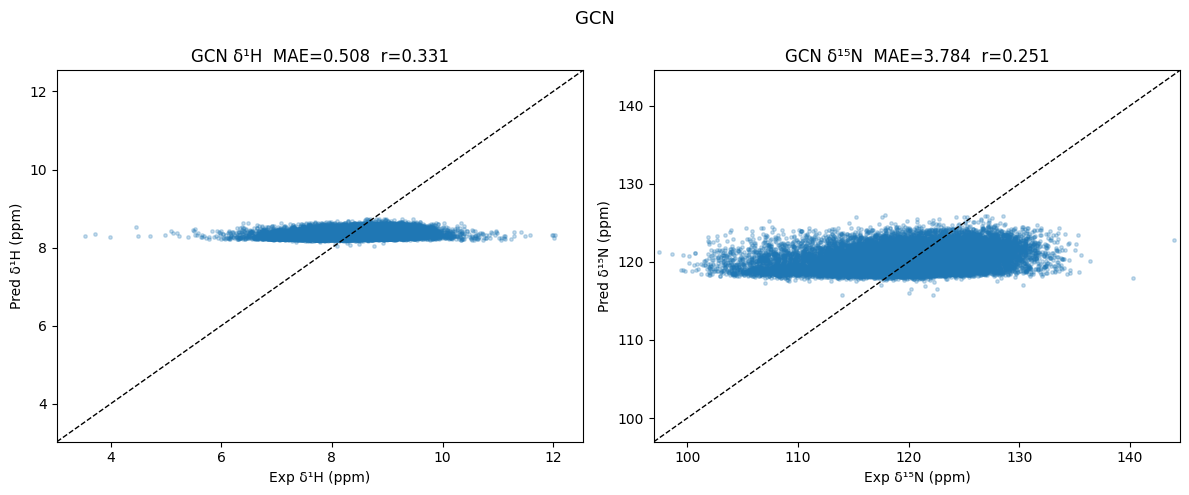

Saved: /content/drive/MyDrive/nmr_hsqc_predictor/output/scatter_gcn.png

=== MLP Test Results ===
  mae_H   : 0.4408  [<0.3]  FAIL
  mae_N   : 3.4102  [<2.0]  FAIL
  r_H     : 0.5094  [>0.9]  FAIL
  r_N     : 0.4944  [>0.9]  FAIL


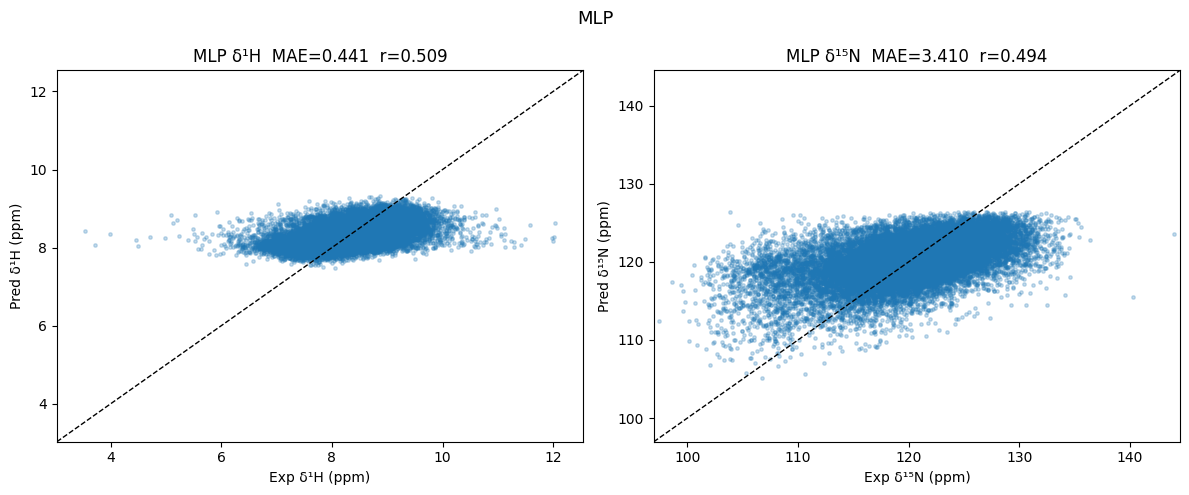

Saved: /content/drive/MyDrive/nmr_hsqc_predictor/output/scatter_mlp.png


In [13]:
def collect(model, ckpt, loader):
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for b in loader:
            b = b.to(DEVICE)
            preds.append(model(b.x, b.edge_index, b.batch).cpu().numpy())
            trues.append(b.y.cpu().numpy())
    return np.concatenate(trues), np.concatenate(preds)

TARGETS = {"mae_H": ("<", 0.3), "mae_N": ("<", 2.0),
           "r_H":   (">", 0.90), "r_N":  (">", 0.90)}

def report(name, y_true, y_pred):
    mH = float(np.mean(np.abs(y_pred[:,0]-y_true[:,0])))
    mN = float(np.mean(np.abs(y_pred[:,1]-y_true[:,1])))
    rH = float(pearsonr(y_true[:,0], y_pred[:,0])[0])
    rN = float(pearsonr(y_true[:,1], y_pred[:,1])[0])
    m  = {"mae_H": mH, "mae_N": mN, "r_H": rH, "r_N": rN}
    print(f"\n=== {name} Test Results ===")
    for k, (op, thr) in TARGETS.items():
        ok = m[k] < thr if op=="<" else m[k] > thr
        print(f"  {k:<8}: {m[k]:.4f}  [{op}{thr}]  {'PASS' if ok else 'FAIL'}")
    return m, y_true, y_pred

def scatter(name, y_true, y_pred, metrics):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, col, lbl, thr_mae in [(axes[0],0,"¹H",0.3),(axes[1],1,"¹⁵N",2.0)]:
        xt, xp = y_true[:,col], y_pred[:,col]
        ax.scatter(xt, xp, alpha=0.25, s=6, rasterized=True)
        lo = min(xt.min(),xp.min())-.5; hi = max(xt.max(),xp.max())+.5
        ax.plot([lo,hi],[lo,hi],"k--",lw=1)
        ax.set(xlim=[lo,hi], ylim=[lo,hi],
               xlabel=f"Exp δ{lbl} (ppm)", ylabel=f"Pred δ{lbl} (ppm)")
        key = "H" if col==0 else "N"
        ax.set_title(f"{name} δ{lbl}  MAE={metrics[f'mae_{key}']:.3f}  r={metrics[f'r_{key}']:.3f}")
    fig.suptitle(name, fontsize=13)
    plt.tight_layout()
    path = f"{OUTPUT_DIR}/scatter_{name.lower()}.png"
    fig.savefig(path, dpi=150); plt.show()
    print(f"Saved: {path}")

# collect results for GCN
yt_gcn, yp_gcn = collect(gcn_model, CKPT_GCN, test_loader)
gcn_metrics, _, _ = report("GCN", yt_gcn, yp_gcn)
scatter("GCN", yt_gcn, yp_gcn, gcn_metrics)

# collect results for MLP
yt_mlp, yp_mlp = collect(mlp_model, CKPT_MLP, test_loader)
mlp_metrics, _, _ = report("MLP", yt_mlp, yp_mlp)
scatter("MLP", yt_mlp, yp_mlp, mlp_metrics)

NameError: name 'gcn_hist' is not defined

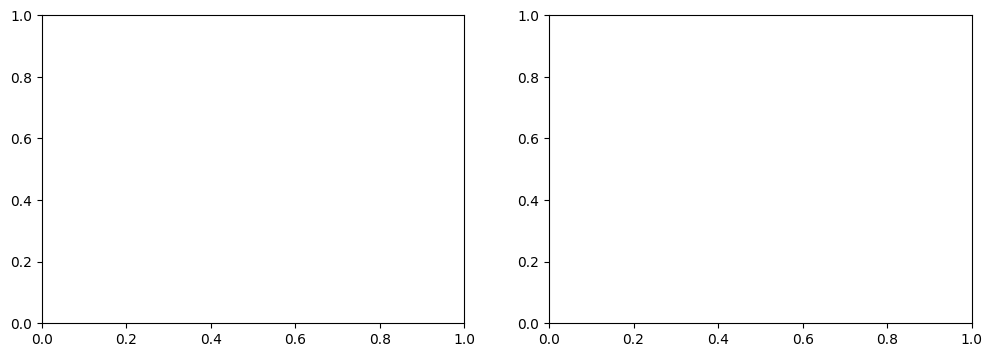

In [17]:
# ── Training loss curves ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, name in [(axes[0], gcn_hist, "GCN"), (axes[1], mlp_hist, "MLP")]:
    eps  = [h[0] for h in hist]
    maes = [h[2]+h[3] for h in hist]   # combined val MAE (H + N)
    ax.plot(eps, maes)
    ax.set(xlabel="Epoch", ylabel="Val MAE ¹H+¹⁵N (ppm)", title=f"{name} training")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150)
plt.show()


## 7 · Inference on a New PDB
Upload any `.pdb` to Colab and predict its HSQC spectrum.

In [26]:
def predict_pdb(pdb_file, model):
    """Returns DataFrame: chain, seq_id, res_name, pred_1H, pred_15N"""
    res_atoms, flex_ok = load_residue_atoms(pdb_file, CFG["bb_cutoff"])
    if not res_atoms:
        raise ValueError(f"No residues parsed from {pdb_file}")

    chain_ord = defaultdict(list)
    for k in sorted(res_atoms, key=lambda x: x[1]):
        chain_ord[k[0]].append(k)
    seq_order = [k for v in chain_ord.values() for k in v]

    feats = {}
    for k in seq_order:
        if flex_ok is not None and k not in flex_ok: continue
        v = embed_residue(k, res_atoms, seq_order, CFG)
        if v is not None: feats[k] = v

    valid = [k for k in seq_order if k in feats]
    if not valid:
        raise ValueError("No residues survived embedding")

    X  = torch.tensor(np.stack([feats[k] for k in valid]), dtype=torch.float32).to(DEVICE)
    ei = build_edges(valid, res_atoms, CFG).to(DEVICE)

    model.eval()
    with torch.no_grad():
        pred = model(X, ei).cpu().numpy()

    return pd.DataFrame([{
        "chain": ch, "seq_id": sq, "res_name": rn,
        "pred_1H": round(float(pred[i,0]),4),
        "pred_15N": round(float(pred[i,1]),4)
    } for i, (ch,sq,rn) in enumerate(valid)])


# ── Example: predict first test protein ───────────────────
ex_pid  = test_ids[0]
ex_pdb  = next(r["pdb_path"] for r in manifest if r["bmrb_id"] == ex_pid)
gcn_model.load_state_dict(torch.load(CKPT_GCN, map_location=DEVICE))

df = predict_pdb(ex_pdb, gcn_model)
print(f"Predictions for BMRB {ex_pid} ({ex_pdb}):")
print(df.head(10).to_string(index=False))

out_csv = f"{OUTPUT_DIR}/pred_{ex_pid}.csv"
df.to_csv(out_csv, index=False)
print(f"\nFull predictions saved to {out_csv}")


Predictions for BMRB 30285 (/content/drive/MyDrive/nmr_hsqc_predictor/data/raw/pdb/5vkg.pdb):
chain  seq_id res_name  pred_1H  pred_15N
    A       2      ALA   8.3615  120.4108
    A       3      VAL   8.3963  120.9207
    A       4      SER   8.3659  120.4743
    A       5      GLU   8.3659  120.4743
    A       6      SER   8.3362  120.0376
    A       7      GLN   8.3201  119.8009
    A       8      LEU   8.3368  120.0471
    A       9      LYS   8.3211  119.8158
    A      10      LYS   8.2904  119.3652
    A      11      MET   8.3006  119.5147

Full predictions saved to /content/drive/MyDrive/nmr_hsqc_predictor/output/pred_30285.csv


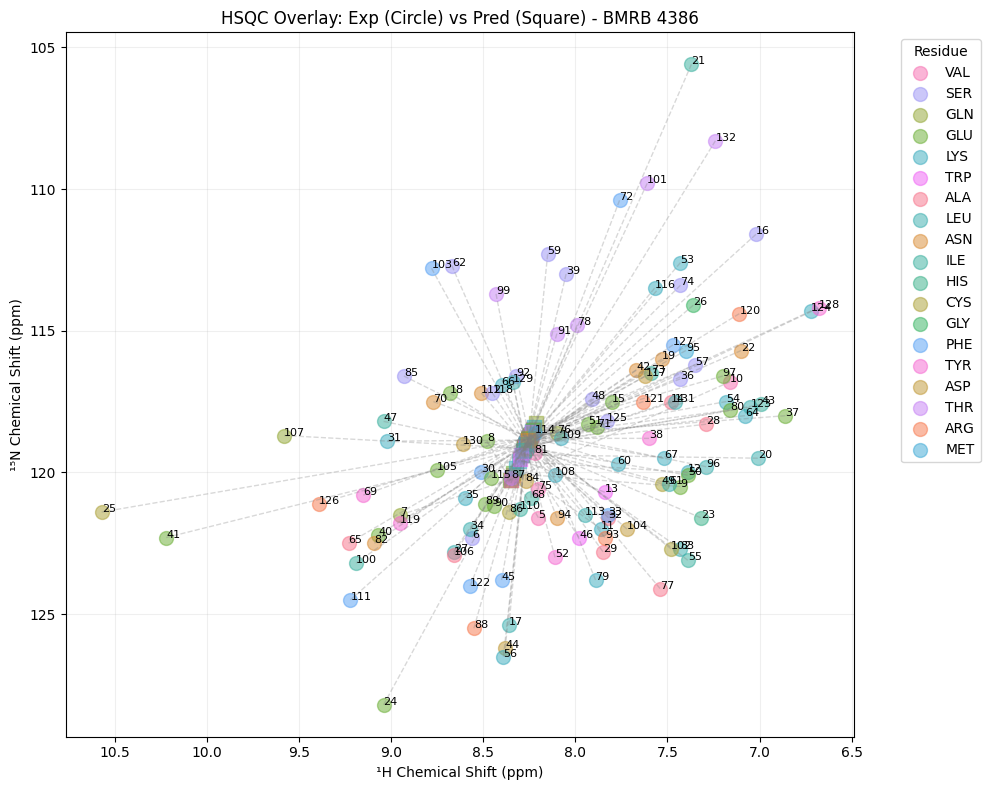

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data for a specific test protein
ex_pid = '4386'
entry = next(r for r in manifest if r['bmrb_id'] == ex_pid)

# Get predictions
df_pred = predict_pdb(entry['pdb_path'], gcn_model)

# Get experimental shifts for overlay
exp_shifts = parse_hsqc_shifts(entry['bmrb_path'])
# Map back to a list that matches our prediction dataframe
exp_list = []
for _, row in df_pred.iterrows():
    # Keys in parse_hsqc_shifts are (chain, seq, res)
    # Note: parse_hsqc_shifts uses '1' for chain often, while PDB uses 'A'
    # We'll try to match by sequence ID and residue name since it's a single chain
    match = None
    for k, v in exp_shifts.items():
        if k[1] == row['seq_id'] and k[2] == row['res_name']:
            match = v
            break
    exp_list.append(match)

df_pred['exp_1H'] = [x[0] if x else None for x in exp_list]
df_pred['exp_15N'] = [x[1] if x else None for x in exp_list]
plot_df = df_pred.dropna(subset=['exp_1H'])

# 2. Plotting
plt.figure(figsize=(10, 8))
res_types = sorted(plot_df['res_name'].unique())
palette = sns.color_palette("husl", len(res_types))
color_map = dict(zip(res_types, palette))

for _, row in plot_df.iterrows():
    color = color_map[row['res_name']]
    # Experimental
    plt.scatter(row['exp_1H'], row['exp_15N'], marker='o', s=100,
                color=color, alpha=0.5, label=row['res_name'] if row['res_name'] not in plt.gca().get_legend_handles_labels()[1] else "")
    # Predicted
    plt.scatter(row['pred_1H'], row['pred_15N'], marker='s', s=100,
                color=color, alpha=0.5)
    # Line connecting pair
    plt.plot([row['exp_1H'], row['pred_1H']], [row['exp_15N'], row['pred_15N']],
             color='gray', linestyle='--', alpha=0.3, lw=1)
    # Label by seq_id
    plt.text(row['exp_1H'], row['exp_15N'], str(row['seq_id']), fontsize=8)

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.xlabel("¹H Chemical Shift (ppm)")
plt.ylabel("¹⁵N Chemical Shift (ppm)")
plt.title(f"HSQC Overlay: Exp (Circle) vs Pred (Square) - BMRB {ex_pid}")
plt.grid(True, alpha=0.2)
# Unique legend labels
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Residue", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# ── Predict any uploaded PDB ────────────────────────────────
# Upload a PDB via the Colab file picker, then set MY_PDB below.
# from google.colab import files
# uploaded = files.upload()
# MY_PDB = list(uploaded.keys())[0]

# Uncomment below after uploading:
# df_custom = predict_pdb(MY_PDB, gcn_model)
# print(df_custom.to_string(index=False))
# df_custom.to_csv(f"{OUTPUT_DIR}/pred_custom.csv", index=False)
print("Uncomment lines above after uploading your own PDB file.")


#Colab saves structured output after each run

In [28]:
import json, subprocess, shutil
from datetime import datetime

# Check if history exists in memory; if not, try to load from the saved JSON
if 'gcn_hist' not in globals() or 'mlp_hist' not in globals():
    hist_path = f"{R}/checkpoints/training_history.json"
    if os.path.exists(hist_path):
        print(f"Loading history from {hist_path}...")
        with open(hist_path) as f:
            hist_data = json.load(f)
        gcn_hist = [(d['ep'], d['loss'], d['mae_H'], d['mae_N']) for d in hist_data['gcn']]
        mlp_hist = [(d['ep'], d['loss'], d['mae_H'], d['mae_N']) for d in hist_data['mlp']]
    else:
        raise NameError("Training history not found in memory or on Drive. Please run the training or history-loading cells first.")

RUN_ID  = datetime.now().strftime("%Y-%m-%d_%H%M")
RUN_DIR = f"{CFG['drive_root']}/runs/{RUN_ID}"
os.makedirs(f"{RUN_DIR}/figures", exist_ok=True)

# 1. Metrics
metrics_out = {
    "run_id":    RUN_ID,
    "n_train":   len(train_ds),
    "n_val":     len(val_ds),
    "n_test":    len(test_ds),
    "gcn": {"mae_H": gcn_metrics["mae_H"], "mae_N": gcn_metrics["mae_N"],
            "r_H":   gcn_metrics["r_H"],   "r_N":   gcn_metrics["r_N"],
            "best_val_mae": min(h[2]+h[3] for h in gcn_hist),
            "stopped_epoch": len(gcn_hist)},
    "mlp": {"mae_H": mlp_metrics["mae_H"], "mae_N": mlp_metrics["mae_N"],
            "r_H":   mlp_metrics["r_H"],   "r_N":   mlp_metrics["r_N"],
            "best_val_mae": min(h[2]+h[3] for h in mlp_hist),
            "stopped_epoch": len(mlp_hist)},
}
with open(f"{RUN_DIR}/metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

# 2. Config snapshot
with open(f"{RUN_DIR}/run_meta.json", "w") as f:
    json.dump({"run_id": RUN_ID, "cfg": CFG,
               "n_proteins_total": len(graph_map),
               "skip_count": skip}, f, indent=2)

# 3. Training history
with open(f"{RUN_DIR}/training_log.txt", "w") as f:
    for ep, loss, mH, mN in gcn_hist:
        f.write(f"GCN ep={ep:3d} loss={loss:.4f} maeH={mH:.4f} maeN={mN:.4f}\n")
    for ep, loss, mH, mN in mlp_hist:
        f.write(f"MLP ep={ep:3d} loss={loss:.4f} maeH={mH:.4f} maeN={mN:.4f}\n")

# 4. Figures — copy from output dir
for fname in os.listdir(OUTPUT_DIR):
    if fname.endswith(".png"):
        shutil.copy(f"{OUTPUT_DIR}/{fname}", f"{RUN_DIR}/figures/{fname}")

print(f"Run saved to: {RUN_DIR}")

NameError: name 'gcn_hist' is not defined